In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

class colors:
    purp = '\033[95m'  # Purple color
    blue = '\033[94m'  # Blue color
    green = '\033[92m'  # Green color
    yell = '\033[93m'  # Yellow color
    red = '\033[91m'  # Red color
    fiolet = '\033[35m'
    bir = '\033[36m'  #бирюзовый
    bold = '\033[1m'  # Bold
    uline = '\033[4m'  # Underline
    endc = '\033[0m'  # End of color line

###0. Выбрать задачу.

Задача регрессии (оценка целевого признака из области действительных чисел). Построить не менее 3 моделей (линейная, дерево и любая другая на выбор).

###1. Подобрать и скачать набор данных.
###2. Подписать блокнот, описать используемый набор данных, указать ссылку на источник.

Т.к. в мудл в 100500-й раз поменяли пароли, а етис жестко лежит, то я взяла датасет boston.csv с сайта про машинное обучение: https://www.dmitrymakarov.ru/

Каждая единица данных — это район города Бостон.
CRIM - информация об уровне преступности
NOX - качестве воздуха
RAD - транспортной доступности
TAX - налоги
PTRATIO - количество учителей
LSTAT - социальное положение населения
и остальные показатели (не сказано какие..)

###3. Сформулировать решаемую задачу, выбрать целевую переменную для задачи классификации или регрессии.

Задача регрессии: предсказать стоимость недвидимости на основе её характеристик

Цель: создать модель, которая сможет прогнозировать стоимость с высокой точностью, основываясь на предоставленных данных.

Целевой переменной является медианная цена недвижимости в каждом из районов - MEDV

###4. Загрузить данные в датафрейм.

In [3]:
boston_df = pd.read_csv('/content/drive/MyDrive/boston.csv')
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


###5. Вывести статистическую информацию о наборе данных.

In [5]:
boston_df.describe().round(3)   #округляем до 3-х знаков после запятой, а то слишком большие циферки..

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000,506.000
mean,3.614,11.364,11.137,0.069,0.555,6.285,68.575,3.795,9.549,408.237,18.456,356.674,12.653,22.533
std,8.602,23.322,6.860,0.254,0.116,0.703,28.149,2.106,8.707,168.537,2.165,91.295,7.141,9.197
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.000,0.449,5.885,45.025,2.100,4.000,279.000,17.400,375.378,6.950,17.025
50%,0.257,0.000,9.690,0.000,0.538,6.208,77.500,3.207,5.000,330.000,19.050,391.440,11.360,21.200
75%,3.677,12.500,18.100,0.000,0.624,6.624,94.075,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.126,24.000,711.000,22.000,396.900,37.970,50.000


###6. Вывести названия столбцов и строк.

In [7]:
print(f"{colors.purp}{colors.bold}\nстолбцы: {boston_df.columns}{colors.endc}\n")
print(f"{colors.green}{colors.bold}\nстроки: {boston_df.index}{colors.endc}\n")


столбцы: Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


строки: RangeIndex(start=0, stop=506, step=1)



###7. Заменить или удалить пропущенные значения.

In [8]:
boston_df = boston_df.dropna()

###8. Заменить категориальные данные количественными.

In [9]:
boston_df.info()  #смотрим, какие типы данных в датасете

#т.к все данные вещественные, то ничего заменять не надо

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


###9. Выбрать важные признаки с помощью корреляционного анализа (оценить их влияние на значение целевого признака в задачах регрессии и классификации).

<Axes: >

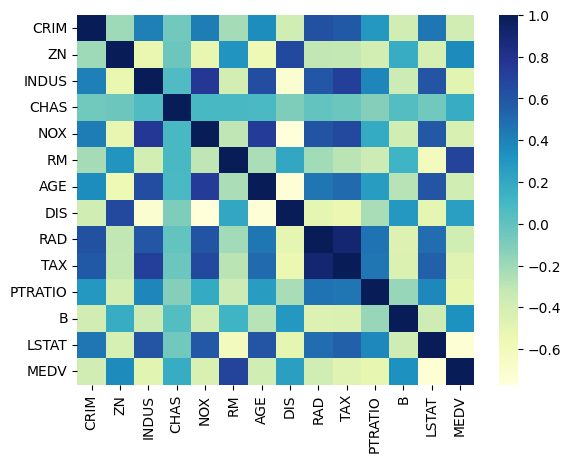

In [15]:
#корелляционная матрица + тепловая карта
sns.heatmap(boston_df.corr(), cmap="YlGnBu")

In [27]:
matrix = boston_df.corr().round(3)
matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000,-0.200,0.407,-0.056,0.421,-0.219,0.353,-0.380,0.626,0.583,0.290,-0.385,0.456,-0.388
ZN,-0.200,1.000,-0.534,-0.043,-0.517,0.312,-0.570,0.664,-0.312,-0.315,-0.392,0.176,-0.413,0.360
INDUS,0.407,-0.534,1.000,0.063,0.764,-0.392,0.645,-0.708,0.595,0.721,0.383,-0.357,0.604,-0.484
CHAS,-0.056,-0.043,0.063,1.000,0.091,0.091,0.087,-0.099,-0.007,-0.036,-0.122,0.049,-0.054,0.175
NOX,0.421,-0.517,0.764,0.091,1.000,-0.302,0.731,-0.769,0.611,0.668,0.189,-0.380,0.591,-0.427
RM,-0.219,0.312,-0.392,0.091,-0.302,1.000,-0.240,0.205,-0.210,-0.292,-0.356,0.128,-0.614,0.695
AGE,0.353,-0.570,0.645,0.087,0.731,-0.240,1.000,-0.748,0.456,0.506,0.262,-0.274,0.602,-0.377
DIS,-0.380,0.664,-0.708,-0.099,-0.769,0.205,-0.748,1.000,-0.495,-0.534,-0.232,0.292,-0.497,0.250
RAD,0.626,-0.312,0.595,-0.007,0.611,-0.210,0.456,-0.495,1.000,0.910,0.465,-0.444,0.489,-0.382
TAX,0.583,-0.315,0.721,-0.036,0.668,-0.292,0.506,-0.534,0.910,1.000,0.461,-0.442,0.544,-0.469


In [22]:
#берём признаки с высокой корреляцией с целевой переменной
X = boston_df[['RM', 'LSTAT', 'PTRATIO', 'TAX', 'INDUS']]   #признаки
Y = boston_df['MEDV'] #целевая функция

###10. Выполнить любые другие действия по конструированию признаков на ваше усмотрение.

---

###11. Визуализировать данные с помощью Matplotlib и Seaborn.


Text(0.5, 1.0, 'Среднее количество комнат и цены на жилье')

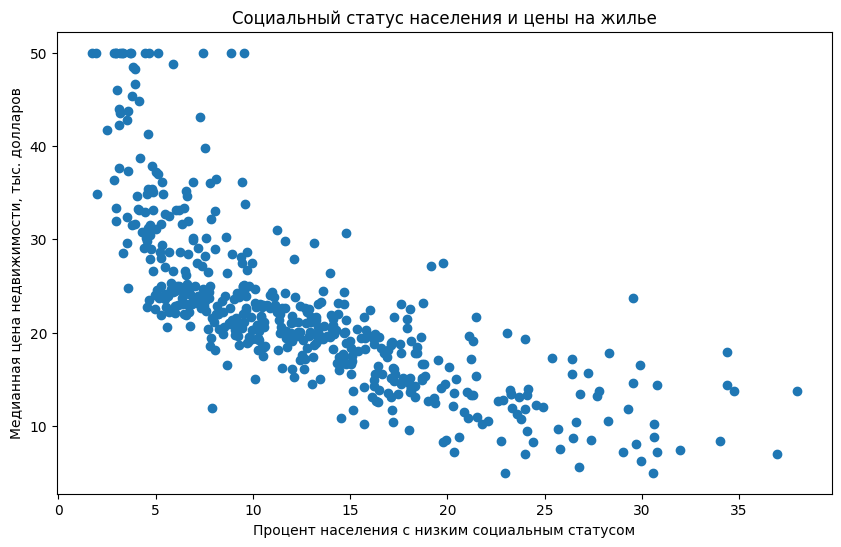

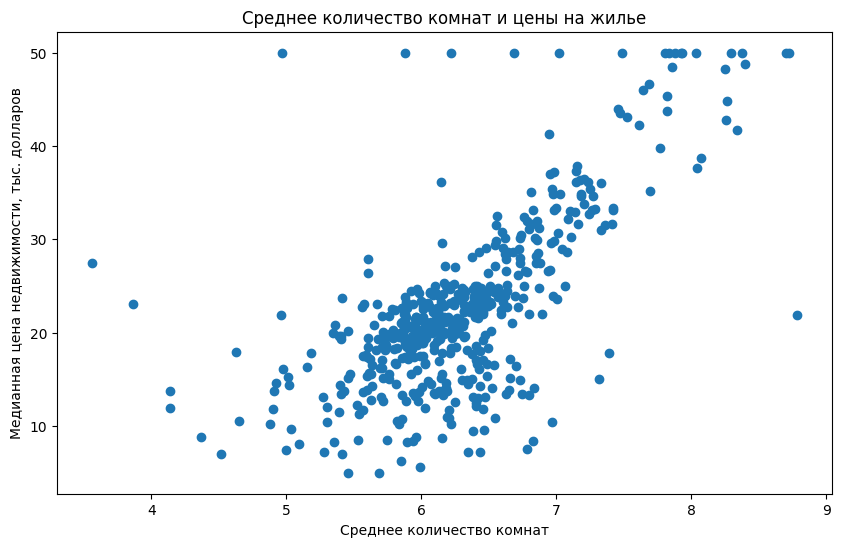

In [33]:
x1 = boston_df['LSTAT']
x2 = boston_df['RM']
y = boston_df['MEDV']

#для х1
plt.figure(figsize = (10,6))
plt.scatter(x1, y)
plt.xlabel('Процент населения с низким социальным статусом')
plt.ylabel('Медианная цена недвижимости, тыс. долларов')
plt.title('Социальный статус населения и цены на жилье')

#для х2
plt.figure(figsize = (10,6))
plt.scatter(x2, y)
plt.xlabel('Среднее количество комнат')
plt.ylabel('Медианная цена недвижимости, тыс. долларов')
plt.title('Среднее количество комнат и цены на жилье')

###12. Выбрать и обосновать выбор метрик.

Буду использовать следующие метрики:
- Средняя квадратичная ошибка (MSE): измеряет среднюю квадратичную разницу между прогнозируемыми и фактическими значениями. Учитывает разницу между прогнозом и фактом, что позволяет отсмотреть большие ошибки.

- Коэффициент детерминации (R^2): представляет долю зависимой переменной, объясненной моделью. Показывает, насколько хорошо данные соответствуют модели и может помочь определить, насколько хорошо модель подходит для прогнозирования.

###13. Построить модели и обучить их. Подбор значений гиперпараметров можно выполнить вручную либо с использованием библиотек Optuna, GridSearch и т.д.


In [34]:
# разобьем данные на обучающую и тестовую выборки

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3,random_state = 42)

In [40]:
#линейная регрессия
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X_train, Y_train)

LinearRegression()

In [59]:
#полиномиальная регрессия
from sklearn.preprocessing import PolynomialFeatures
model2 = LinearRegression() # Полиномиальная регрессия
quadratic = PolynomialFeatures(degree=2)
X_quad = quadratic.fit_transform(X_train)       #преобразуем данные

model2.fit(X_quad, Y_train)   #обучаем полиномиальную регрессию

LinearRegression()

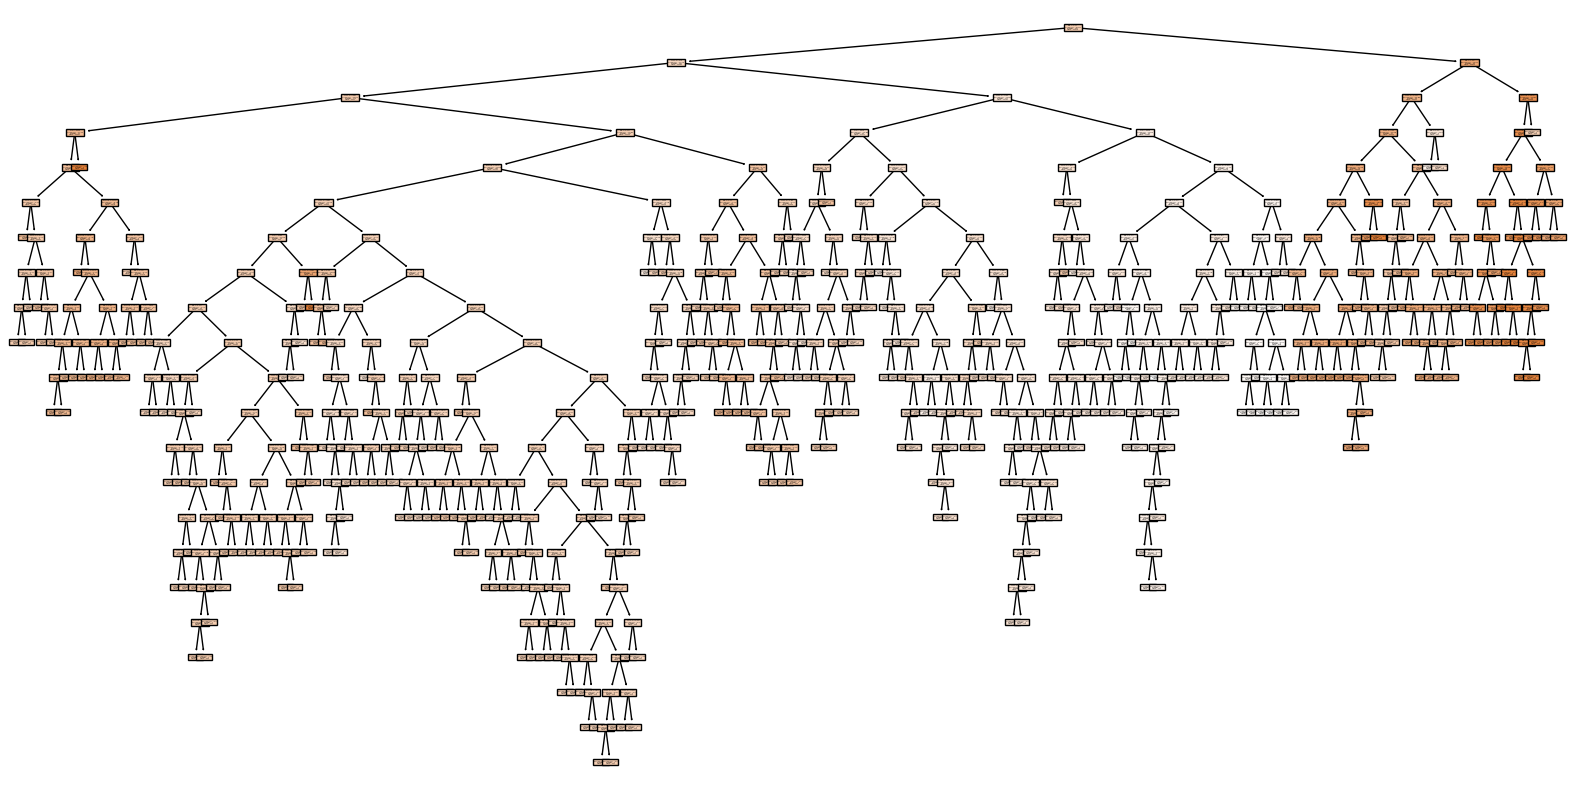

In [56]:
#дерево
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

model3 = DecisionTreeRegressor()
model3.fit(X_train, Y_train)

plt.figure(figsize=(20,10))
plot_tree(model3, filled=True, feature_names=X.columns, class_names=['0', '1'])
plt.show()

###14. Рассчитать значения метрик.


In [65]:
from sklearn import metrics
from sklearn.metrics import r2_score, mean_squared_error

In [82]:
#линейная регрессия

#делаем предсказание на цену (Y) на основе нескольких независимых переменных (Х)
y_pred1 = model1.predict(X_test)
print(y_pred1[:5], '\n')

#рассчитываем метрики
print(f"{colors.purp}{colors.bold}Для линейной регрессии:{colors.endc}")
print(f"{colors.purp}среднеквадратичная ошибка: {np.sqrt(mean_squared_error(Y_test, y_pred1))} \nкоэффициент детерминации {np.round(metrics.r2_score(Y_test, y_pred1), 2)}{colors.endc}", '\n')



[26.62981059 31.10008241 16.95701338 25.59771173 18.09307064] 

Для линейной регрессии:
среднеквадратичная ошибка: 5.107447670220913 
коэффициент детерминации 0.65 



In [110]:
#полиномиальная регрессия

#предсказания
y_pred2 = model2.predict(quadratic.fit_transform(X_test))
print(y_pred2[:5], '\n')

#метрики
print(f"{colors.blue}{colors.bold}Для полиномиальной регрессии:{colors.endc}")
print(f"{colors.blue}среднеквадратичная ошибка: {np.sqrt(mean_squared_error(Y_test, y_pred2))} \nкоэффициент детерминации {np.round(metrics.r2_score(Y_test, y_pred2), 3)}{colors.endc}", '\n')

[24.87395035 32.00011508 16.2214512  24.7671942  15.37454885] 

Для полиномиальной регрессии:
среднеквадратичная ошибка: 3.8746281086624696 
коэффициент детерминации 0.799 



In [127]:
res1 = 'линейная регрессия лучше по R^2' if r2_score(Y_test, y_pred1) > r2_score(Y_test, y_pred2) else 'полиномиальная модель лучше по R^2'
res2 = 'линейная регрессия лучше по MSE' if mean_squared_error(Y_test, y_pred1) < mean_squared_error(Y_test, y_pred2) else 'полиномиальная модель лучше по MSE'
print(f"{colors.uline}{colors.bold}{colors.green}{res1}\n{res2}{colors.endc}")

полиномиальная модель лучше по R^2
полиномиальная модель лучше по MSE


In [129]:
#дерево

#предсказания
y_pred3 = model3.predict(X_test)
print(y_pred3[:5], '\n')

#метрики
print(f"{colors.bir}{colors.bold}Для дерева:{colors.endc}")
print(f"{colors.bir}среднеквадратичная ошибка: {np.sqrt(mean_squared_error(Y_test, y_pred3))} \nкоэффициент детерминации {np.round(metrics.r2_score(Y_test, y_pred3), 3)}{colors.endc}", '\n')

[23.6 32.4 13.6 22.8 16.1] 

Для дерева:
среднеквадратичная ошибка: 0.0 
коэффициент детерминации 1.0 



###15. Проанализировать полученные результаты обучения, выбрав наилучшую модель. Обосновать выбор.

Лучшей моделью оказалось дерево, т.к. R^2 = 1, т.е. 100% целевой функции объясняется независимыми переменными + ошибка = 0.

но если выбирать между линейной и полиномиальной регрессиями, то по метрикам лучше полиномиальная.

###16. Оформить отчёт.
нуу, собственно говоря, весь этот док и есть отчётный отчёт

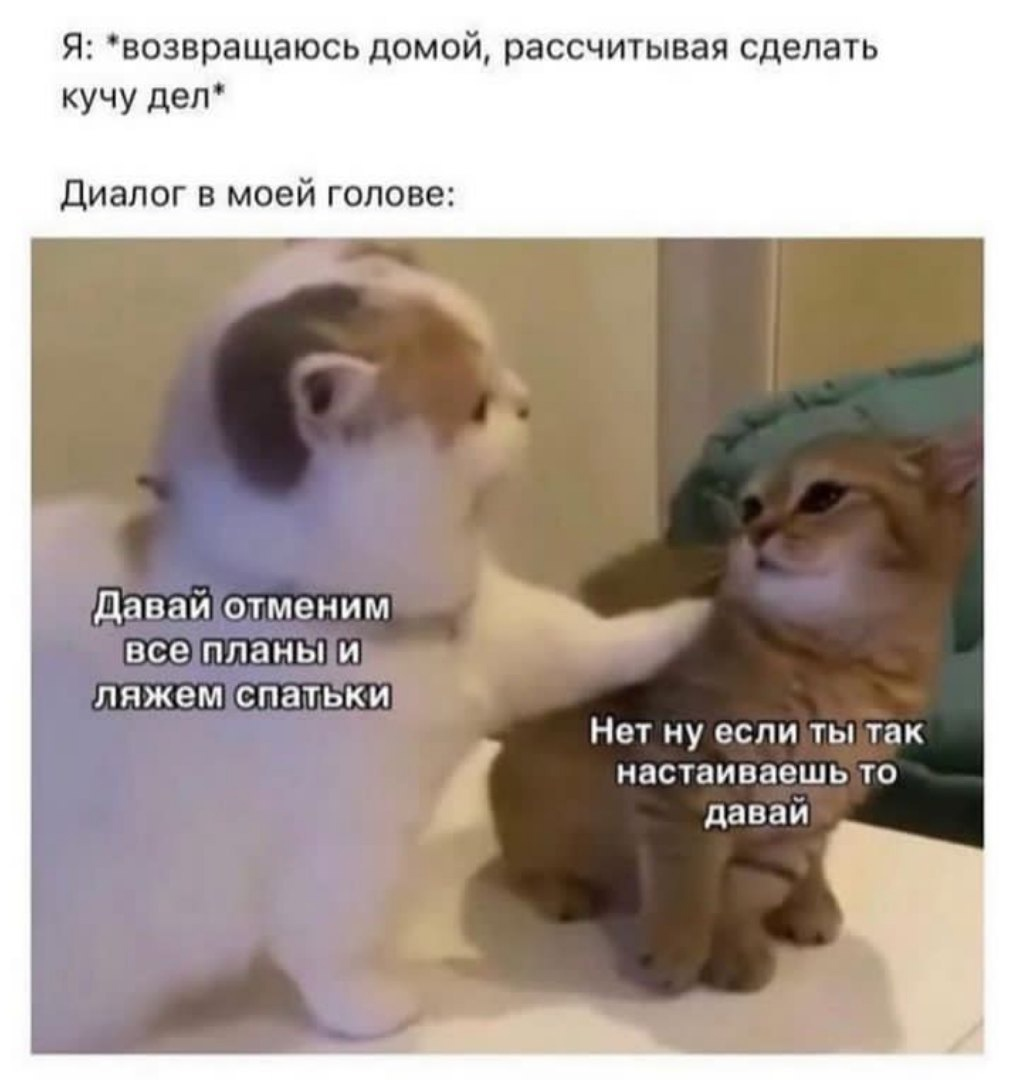